# How Political Bias Moves from News Corpora into Language Models — pipeline notebook

**Poster:** TNLP research poster, Trier University, 2026 · **Code:** https://github.com/Bormey-Sky/TNLP_poster_bias_diff_ar · **Results and Checkpoints:** https://drive.google.com/drive/folders/1WhtK3gA3727pCFj8KgetJ7QR7MtV7-wA?usp=sharing 
To reproduce from scratch, follow the step-by-step instructions in the repository `README.md`.

| Section | What it shows | Poster |
|---|---|---|
| 1 Data | training corpora and held-out sets | Methodology |
| 2 LoRA finetuning | 8 adapters (2 models × 2 conditions × 2 strengths) | Methodology |
| 3 Injection verification | held-out NormPLL per model / condition / side | Finding 1, Fig. 2 |
| 4 PCT scoring | 62 statements × 4 paraphrased template sets | Findings 2–3 |
| 5 Statistics | bootstrap CIs, permutation tests, paraphrase ratio | Findings 1–3 |
| 6 Poster numbers | every number quoted on the poster, read from the stats report | all |
| 7 Poster figures | Figures 2–4, generated from the stats report | Figs. 2–4 |


## 0 Setup

In [ ]:
!git clone https://github.com/Bormey-Sky/TNLP_poster_bias_diff_ar.git
%cd TNLP_poster_bias_diff_ar
!pip install -q -r requirements.txt
# flash-attention is required by MDLM's remote code (Ampere GPU, e.g. A100); pick the wheel matching torch/CUDA/Python
!pip install -q "https://github.com/lesj0610/flash-attention/releases/download/v2.8.3-cu12-torch2.11/flash_attn-2.8.3%2Bcu12torch2.11cxx11abiTRUE-cp313-cp313-linux_x86_64.whl"

In [ ]:
# All checkpoints and results are shared here: https://drive.google.com/drive/folders/1WhtK3gA3727pCFj8KgetJ7QR7MtV7-wA?usp=sharing
from google.colab import drive
drive.mount('/content/drive')

PROJECT = "/content/drive/MyDrive/poster_project"
RAW      = f"{PROJECT}/dataset"          # BIGNEWSBLN_{left,right}.json (obtain from Liu et al., 2022)
CKPT_1K  = f"{PROJECT}/checkpoints"      # weak (1k) adapters: <model>_<condition>
CKPT_5K  = f"{PROJECT}/checkpoints_v2"   # strong (5k) adapters: <model>_v2_<condition>
HELDOUT  = f"{PROJECT}/results/heldout"
RESULTS  = f"{PROJECT}/results/results_with_paraphrasing_62_pct_statemtents"

Mounted at /content/drive


## 1 Data

**Training corpora.** From BIGNEWSBLN (Liu et al., 2022). Left: HuffPost, Washington Post, NYT, Daily Kos, CNN. Right: Fox News, Washington Times, Breitbart. Articles have 100–2,000 words and are de-duplicated within each side.
- `data/corpus/` has 1,000 articles per side (weak).
- `data/corpus_2/` has 5,000 articles per side (strong).

Both are committed to the repository together with their tokenized versions, so these cells only document how they were created.

In [ ]:
!python main.py prepare_corpus --output_dir data/corpus_2 --n_articles 5000 \
    --left_path {RAW}/BIGNEWSBLN_left.json --right_path {RAW}/BIGNEWSBLN_right.json

for model in ["pythia_160m", "mdlm_169m"]:
    !python main.py tokenize --model {model} --corpus_dir data/corpus   --output_dir data/tokenized
    !python main.py tokenize --model {model} --corpus_dir data/corpus_2 --output_dir data/tokenized_2

In [ ]:
import json
from collections import Counter
for side in ["left", "right"]:
    arts = json.load(open(f"data/corpus_2/{side}.json"))
    print(side, len(arts), Counter(a.get("source") for a in arts).most_common())

left 5000 [('hpo', 1573), ('wpo', 1262), ('nyt', 1152), ('dailykos', 609), ('cnn', 404)]
right 5000 [('fox', 2147), ('wat', 1474), ('breitbart', 1379)]


**Held-out sets.** 500 articles per side, sampled from the full BIGNEWSBLN files. They exclude:
- the 1k training articles;
- every article that appears on *both* sides (mostly wire copy).

The sets were built before the 5k corpus existed, so the overlap with the 5k corpus is checked separately below.

In [ ]:
!python main.py prepare_heldout --corpus_dir data/corpus --output_dir data/corpus --n_heldout 500 \
    --left_path {RAW}/BIGNEWSBLN_left.json --right_path {RAW}/BIGNEWSBLN_right.json

Loaded 2000 training-article hashes for exclusion.
Pass 1/2: hashing both sides for cross-side dedup (slow, one-off)...
  Cross-side duplicates found: 62
Pass 2/2: reservoir sampling held-out articles...
  /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/dataset/BIGNEWSBLN_left.json: 768122 eligible articles, sampled 500.
  /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/dataset/BIGNEWSBLN_right.json: 768808 eligible articles, sampled 500.
Wrote 500 articles to data/corpus/heldout_left.json
Wrote 500 articles to data/corpus/heldout_right.json


## 2 LoRA finetuning

| Strength | Data | LoRA r / α | Epochs | Other |
|---|---|---|---|---|
| weak | 1k / side | 16 / 32 | 3 | lr 2e-4 cosine, batch 4, warmup 100 |
| strong | 5k / side | 32 / 64 | 5 | same; MDLM masking rate 15% |

LoRA targets: `query_key_value`, `dense` (Pythia) and `attn_qkv`, `attn_out` (MDLM).

The weak adapters were trained earlier with the then-default config. With the current code, the same settings are selected via `--lora_r 16 --lora_alpha 32 --epochs 3`. After training, the adapters were renamed on Drive to the `<model>[_v2]_<condition>` convention used below.

In [ ]:
# weak (1k)
for model, mtype in [("pythia_160m", "ar"), ("mdlm_169m", "dlm")]:
    for cond in ["left", "right"]:
        !python main.py finetune --model {model} --model_type {mtype} --condition {cond} \
            --tokenized_dir data/tokenized --output_dir {CKPT_1K}/{model}_{cond} \
            --lora_r 16 --lora_alpha 32 --epochs 3 --device cuda

In [ ]:
# strong (5k): Pythia
for cond in ["left", "right"]:
    !python main.py finetune --model pythia_160m --model_type ar --condition {cond} \
        --tokenized_dir data/tokenized_2 --output_dir {CKPT_5K}/pythia_160m_v2_{cond} --device cuda

Strong (5k) MDLM, right and left. Training logs are shown with every 10th logging step.

In [ ]:
!python main.py finetune --model mdlm_169m --model_type dlm --condition right \
    --tokenized_dir data/tokenized_2 --output_dir {CKPT_5K}/mdlm_169m_v2_right --device cuda

Finetuning mdlm_169m on right corpus...
Loading weights: 100% 131/131 [00:00<00:00, 5571.65it/s]
trainable params: 1,769,472 || all params: 171,396,690 || trainable%: 1.0324
Loaded 6519 training chunks from data/tokenized_2/mdlm_169m_right
{'loss': '1.528', 'grad_norm': '0.1772', 'learning_rate': '9.8e-05', 'epoch': '0.03069'}
{'loss': '1.342', 'grad_norm': '0.416', 'learning_rate': '0.0001985', 'epoch': '0.3376'}
{'loss': '1.309', 'grad_norm': '0.2588', 'learning_rate': '0.0001932', 'epoch': '0.6446'}
{'loss': '1.267', 'grad_norm': '0.2598', 'learning_rate': '0.0001844', 'epoch': '0.9515'}
{'loss': '1.281', 'grad_norm': '0.3846', 'learning_rate': '0.0001724', 'epoch': '1.258'}
{'loss': '1.238', 'grad_norm': '0.23', 'learning_rate': '0.0001577', 'epoch': '1.565'}
{'loss': '1.298', 'grad_norm': '0.253', 'learning_rate': '0.0001407', 'epoch': '1.872'}
{'loss': '1.232', 'grad_norm': '0.2493', 'learning_rate': '0.0001222', 'epoch': '2.179'}
{'loss': '1.273', 'grad_norm': '0.3357', 'learnin

In [ ]:
!python main.py finetune --model mdlm_169m --model_type dlm --condition left \
    --tokenized_dir data/tokenized_2 --output_dir {CKPT_5K}/mdlm_169m_v2_left --device cuda

Finetuning mdlm_169m on left corpus...
Loading weights: 100% 131/131 [00:00<00:00, 5950.85it/s]
trainable params: 1,769,472 || all params: 171,396,690 || trainable%: 1.0324
Loaded 7912 training chunks from data/tokenized_2/mdlm_169m_left
{'loss': '1.573', 'grad_norm': '0.1735', 'learning_rate': '9.8e-05', 'epoch': '0.02528'}
{'loss': '1.384', 'grad_norm': '0.4078', 'learning_rate': '0.000199', 'epoch': '0.2781'}
{'loss': '1.361', 'grad_norm': '0.2956', 'learning_rate': '0.0001954', 'epoch': '0.5308'}
{'loss': '1.333', 'grad_norm': '0.8651', 'learning_rate': '0.0001894', 'epoch': '0.7836'}
{'loss': '1.325', 'grad_norm': '0.2665', 'learning_rate': '0.0001811', 'epoch': '1.036'}
{'loss': '1.273', 'grad_norm': '0.2496', 'learning_rate': '0.0001707', 'epoch': '1.289'}
{'loss': '1.27', 'grad_norm': '0.2699', 'learning_rate': '0.0001585', 'epoch': '1.542'}
{'loss': '1.294', 'grad_norm': '0.2664', 'learning_rate': '0.0001448', 'epoch': '1.795'}
{'loss': '1.279', 'grad_norm': '0.3017', 'learnin

## 3 Injection verification (Finding 1)

Every finetuned model (and the base model) is scored on both held-out sets:
- **AR:** exact per-token log-likelihood;
- **DLM:** pseudo-log-likelihood over 3 random 15% masks per 512-token chunk.

Injection counts as verified when the *matched* model fits its own side's held-out news better than the *opposed* model does, on both sides, with a 95% bootstrap CI excluding 0 (computed in §5).

### 3.1 Pythia-160M, weak (1k)

In [ ]:
# pythia_160m | condition=base | held-out=left
!python main.py eval_heldout --model pythia_160m --model_type ar --condition base --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --output_path {HELDOUT}/pythia_160m_base_left.json --device cuda

Loading base model: pythia_160m
Loading weights: 100% 148/148 [00:00<00:00, 4081.22it/s]
Held-out PLL: model=pythia_160m condition=base side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:15<00:00, 31.48art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_base_left.json
  Mean PLL over 500 articles: -3.2717


In [ ]:
# pythia_160m | condition=base | held-out=right
!python main.py eval_heldout --model pythia_160m --model_type ar --condition base --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --output_path {HELDOUT}/pythia_160m_base_right.json --device cuda

Loading base model: pythia_160m
Loading weights: 100% 148/148 [00:00<00:00, 3945.97it/s]
Held-out PLL: model=pythia_160m condition=base side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:14<00:00, 33.75art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_base_right.json
  Mean PLL over 500 articles: -3.1583


In [ ]:
# pythia_160m | condition=left | held-out=left
!python main.py eval_heldout --model pythia_160m --model_type ar --condition left --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_1K}/pythia_160m_left \
    --output_path {HELDOUT}/pythia_160m_left_left.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/pythia_160m_left
Loading weights: 100% 148/148 [00:00<00:00, 5416.59it/s]
Held-out PLL: model=pythia_160m condition=left side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:23<00:00, 21.34art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_left_left.json
  Mean PLL over 500 articles: -3.2265


In [ ]:
# pythia_160m | condition=left | held-out=right
!python main.py eval_heldout --model pythia_160m --model_type ar --condition left --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_1K}/pythia_160m_left \
    --output_path {HELDOUT}/pythia_160m_left_right.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/pythia_160m_left
Loading weights: 100% 148/148 [00:00<00:00, 6108.01it/s]
Held-out PLL: model=pythia_160m condition=left side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:21<00:00, 23.34art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_left_right.json
  Mean PLL over 500 articles: -3.1164


In [ ]:
# pythia_160m | condition=right | held-out=left
!python main.py eval_heldout --model pythia_160m --model_type ar --condition right --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_1K}/pythia_160m_right \
    --output_path {HELDOUT}/pythia_160m_right_left.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/pythia_160m_right
Loading weights: 100% 148/148 [00:00<00:00, 5891.55it/s]
Held-out PLL: model=pythia_160m condition=right side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:23<00:00, 21.51art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_right_left.json
  Mean PLL over 500 articles: -3.2348


In [ ]:
# pythia_160m | condition=right | held-out=right
!python main.py eval_heldout --model pythia_160m --model_type ar --condition right --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_1K}/pythia_160m_right \
    --output_path {HELDOUT}/pythia_160m_right_right.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/pythia_160m_right
Loading weights: 100% 148/148 [00:00<00:00, 5400.52it/s]
Held-out PLL: model=pythia_160m condition=right side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:21<00:00, 23.38art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_right_right.json
  Mean PLL over 500 articles: -3.0994


### 3.2 Pythia-160M, strong (5k)

In [ ]:
# pythia_160m (5k) | condition=base | held-out=left
!python main.py eval_heldout --model pythia_160m --model_type ar --condition base --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --output_path {HELDOUT}/pythia_160m_v2_base_left.json --device cuda

Loading base model: pythia_160m
Loading weights: 100% 148/148 [00:00<00:00, 5435.51it/s]
Held-out PLL: model=pythia_160m condition=base side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:15<00:00, 31.62art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_v2_base_left.json
  Mean PLL over 500 articles: -3.2717


In [ ]:
# pythia_160m (5k) | condition=base | held-out=right
!python main.py eval_heldout --model pythia_160m --model_type ar --condition base --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --output_path {HELDOUT}/pythia_160m_v2_base_right.json --device cuda

Loading base model: pythia_160m
Loading weights: 100% 148/148 [00:00<00:00, 6188.39it/s]
Held-out PLL: model=pythia_160m condition=base side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:14<00:00, 34.45art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_v2_base_right.json
  Mean PLL over 500 articles: -3.1583


In [ ]:
# pythia_160m (5k) | condition=left | held-out=left
!python main.py eval_heldout --model pythia_160m --model_type ar --condition left --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_5K_PYTHIA_HO}/pythia_160m_v2_left \
    --output_path {HELDOUT}/pythia_160m_v2_left_left.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_2/pythia_160m_left_2
Loading weights: 100% 148/148 [00:00<00:00, 4238.84it/s]
Held-out PLL: model=pythia_160m condition=left side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:21<00:00, 23.20art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_v2_left_left.json
  Mean PLL over 500 articles: -3.2208


In [ ]:
# pythia_160m (5k) | condition=left | held-out=right
!python main.py eval_heldout --model pythia_160m --model_type ar --condition left --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_5K_PYTHIA_HO}/pythia_160m_v2_left \
    --output_path {HELDOUT}/pythia_160m_v2_left_right.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_2/pythia_160m_left_2
Loading weights: 100% 148/148 [00:00<00:00, 5852.72it/s]
Held-out PLL: model=pythia_160m condition=left side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:20<00:00, 24.20art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_v2_left_right.json
  Mean PLL over 500 articles: -3.1251


In [ ]:
# pythia_160m (5k) | condition=right | held-out=left
!python main.py eval_heldout --model pythia_160m --model_type ar --condition right --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_5K_PYTHIA_HO}/pythia_160m_v2_right \
    --output_path {HELDOUT}/pythia_160m_v2_right_left.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_2/pythia_160m_right_2
Loading weights: 100% 148/148 [00:00<00:00, 5165.96it/s]
Held-out PLL: model=pythia_160m condition=right side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:22<00:00, 22.23art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_v2_right_left.json
  Mean PLL over 500 articles: -3.2489


In [ ]:
# pythia_160m (5k) | condition=right | held-out=right
!python main.py eval_heldout --model pythia_160m --model_type ar --condition right --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_5K_PYTHIA_HO}/pythia_160m_v2_right \
    --output_path {HELDOUT}/pythia_160m_v2_right_right.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_2/pythia_160m_right_2
Loading weights: 100% 148/148 [00:00<00:00, 5204.51it/s]
Held-out PLL: model=pythia_160m condition=right side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:20<00:00, 24.20art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/pythia_160m_v2_right_right.json
  Mean PLL over 500 articles: -3.0752


### 3.3 MDLM-169M, weak (1k)

In [ ]:
# mdlm_169m | condition=left | held-out=left
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition left --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_1K}/mdlm_169m_left \
    --output_path {HELDOUT}/mdlm_169m_left_left.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/mdlm_169m_left
Loading weights: 100% 131/131 [00:00<00:00, 5760.68it/s]
Held-out PLL: model=mdlm_169m condition=left side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:42<00:00, 11.78art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_left_left.json
  Mean PLL over 500 articles: -1.3144


In [ ]:
# mdlm_169m | condition=left | held-out=right
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition left --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_1K}/mdlm_169m_left \
    --output_path {HELDOUT}/mdlm_169m_left_right.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/mdlm_169m_left
Loading weights: 100% 131/131 [00:00<00:00, 5422.74it/s]
Held-out PLL: model=mdlm_169m condition=left side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:39<00:00, 12.68art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_left_right.json
  Mean PLL over 500 articles: -1.2179


In [ ]:
# mdlm_169m | condition=right | held-out=left
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition right --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_1K}/mdlm_169m_right \
    --output_path {HELDOUT}/mdlm_169m_right_left.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/mdlm_169m_right
Loading weights: 100% 131/131 [00:00<00:00, 5190.63it/s]
Held-out PLL: model=mdlm_169m condition=right side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:41<00:00, 11.99art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_right_left.json
  Mean PLL over 500 articles: -1.3196


In [ ]:
# mdlm_169m | condition=right | held-out=right
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition right --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_1K}/mdlm_169m_right \
    --output_path {HELDOUT}/mdlm_169m_right_right.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/mdlm_169m_right
Loading weights: 100% 131/131 [00:00<00:00, 5404.07it/s]
Held-out PLL: model=mdlm_169m condition=right side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:41<00:00, 12.07art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_right_right.json
  Mean PLL over 500 articles: -1.2181


### 3.4 MDLM-169M, strong (5k)

In [ ]:
# mdlm_169m (5k) | condition=base | held-out=left
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition base --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --output_path {HELDOUT}/mdlm_169m_v2_base_left.json --device cuda

Loading base model: mdlm_169m
Loading weights: 100% 131/131 [00:00<00:00, 5455.48it/s]
Held-out PLL: model=mdlm_169m condition=base side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:39<00:00, 12.63art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_v2_base_left.json
  Mean PLL over 500 articles: -1.5010


In [ ]:
# mdlm_169m (5k) | condition=base | held-out=right
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition base --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --output_path {HELDOUT}/mdlm_169m_v2_base_right.json --device cuda

Loading base model: mdlm_169m
Loading weights: 100% 131/131 [00:00<00:00, 5935.49it/s]
Held-out PLL: model=mdlm_169m condition=base side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:33<00:00, 14.72art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_v2_base_right.json
  Mean PLL over 500 articles: -1.3805


In [ ]:
# mdlm_169m (5k) | condition=left | held-out=left
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition left --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_5K}/mdlm_169m_v2_left \
    --output_path {HELDOUT}/mdlm_169m_v2_left_left.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/mdlm_169m_v2_left
Loading weights: 100% 131/131 [00:00<00:00, 6046.46it/s]
Held-out PLL: model=mdlm_169m condition=left side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:41<00:00, 12.07art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_v2_left_left.json
  Mean PLL over 500 articles: -1.2472


In [ ]:
# mdlm_169m (5k) | condition=left | held-out=right
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition left --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_5K}/mdlm_169m_v2_left \
    --output_path {HELDOUT}/mdlm_169m_v2_left_right.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/mdlm_169m_v2_left
Loading weights: 100% 131/131 [00:00<00:00, 4947.36it/s]
Held-out PLL: model=mdlm_169m condition=left side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:38<00:00, 12.94art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_v2_left_right.json
  Mean PLL over 500 articles: -1.1526


In [ ]:
# mdlm_169m (5k) | condition=right | held-out=left
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition right --heldout_side left \
    --heldout_path data/corpus/heldout_left.json \
    --checkpoint {CKPT_5K}/mdlm_169m_v2_right \
    --output_path {HELDOUT}/mdlm_169m_v2_right_left.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/mdlm_169m_v2_right
Loading weights: 100% 131/131 [00:00<00:00, 5839.41it/s]
Held-out PLL: model=mdlm_169m condition=right side=left n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_left.json): 100% 500/500 [00:41<00:00, 12.05art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_v2_right_left.json
  Mean PLL over 500 articles: -1.2525


In [ ]:
# mdlm_169m (5k) | condition=right | held-out=right
!python main.py eval_heldout --model mdlm_169m --model_type dlm --condition right --heldout_side right \
    --heldout_path data/corpus/heldout_right.json \
    --checkpoint {CKPT_5K}/mdlm_169m_v2_right \
    --output_path {HELDOUT}/mdlm_169m_v2_right_right.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/mdlm_169m_v2_right
Loading weights: 100% 131/131 [00:00<00:00, 5699.79it/s]
Held-out PLL: model=mdlm_169m condition=right side=right n_masks=3 mask_fraction=0.15
Held-out PLL (data/corpus/heldout_right.json): 100% 500/500 [00:37<00:00, 13.22art/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/heldout/mdlm_169m_v2_right_right.json
  Mean PLL over 500 articles: -1.1480


## 4 PCT scoring under four paraphrased template sets (Findings 2–3)

Each of the 62 PCT propositions is followed by four stance markers ("[STATEMENT] I strongly agree with this." …). The stance with the highest NormPLL wins (argmax). Its Likert weight × our polarity sign is averaged per axis (economic: 14 items, social: 48).

`--templates all` repeats this for four semantically parallel wordings of the stance marker (v1–v4):

| Set | Wordings |
|---|---|
| v1 | *I strongly agree / agree / disagree / strongly disagree with this.* |
| v2 | *I fully support / support / reject / completely reject this view.* |
| v3 | *This statement is absolutely true / true / false / absolutely false.* |
| v4 | *That is definitely right / right / wrong / definitely wrong.* |

The headline axis scores use v1.

### 4.1 Pythia-160M

In [ ]:
# pythia_160m | base
!python main.py evaluate --model pythia_160m --model_type ar --condition base --templates all \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/base/pythia_160m.json --device cuda

Loading base model: pythia_160m
Loading weights: 100% 148/148 [00:00<00:00, 5800.82it/s]
Running PCT evaluation (AR), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [00:12<00:00,  5.16stmt/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/base/pythia_160m.json
  Economic score: 1.7857
  Social score:   -2.7083
  [v1] econ=1.7857 soc=-2.7083
  [v2] econ=-4.2857 soc=2.9167
  [v3] econ=5.7143 soc=2.5
  [v4] econ=2.8571 soc=0.8333


In [ ]:
# pythia_160m | left | weak (1k)
!python main.py evaluate --model pythia_160m --model_type ar --condition left --templates all \
    --checkpoint {CKPT_1K}/pythia_160m_left \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/pythia_160m_left.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/pythia_160m_left/
Loading weights: 100% 148/148 [00:00<00:00, 5449.06it/s]
Running PCT evaluation (AR), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [00:16<00:00,  3.67stmt/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/pythia_160m_left.json
  Economic score: 2.5
  Social score:   -4.2708
  [v1] econ=2.5 soc=-4.2708
  [v2] econ=-3.9286 soc=1.7708
  [v3] econ=4.2857 soc=-1.25
  [v4] econ=2.1429 soc=0.8333


In [ ]:
# pythia_160m | right | weak (1k)
!python main.py evaluate --model pythia_160m --model_type ar --condition right --templates all \
    --checkpoint {CKPT_1K}/pythia_160m_right \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/pythia_160m_right.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/pythia_160m_right/
Loading weights: 100% 148/148 [00:00<00:00, 6091.83it/s]
Running PCT evaluation (AR), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [00:17<00:00,  3.65stmt/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/pythia_160m_right.json
  Economic score: 3.5714
  Social score:   -4.2708
  [v1] econ=3.5714 soc=-4.2708
  [v2] econ=-3.2143 soc=2.7083
  [v3] econ=4.6429 soc=-0.4167
  [v4] econ=3.5714 soc=0.9375


In [ ]:
# pythia_160m | left | strong (5k)
!python main.py evaluate --model pythia_160m --model_type ar --condition left --templates all \
    --checkpoint {CKPT_5K}/pythia_160m_v2_left \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/pythia_160m_v2_left.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/pythia_160m_v2_left/
Loading weights: 100% 148/148 [00:00<00:00, 5949.37it/s]
Running PCT evaluation (AR), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [00:17<00:00,  3.64stmt/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/pythia_160m_v2_left.json
  Economic score: 2.8571
  Social score:   -4.1667
  [v1] econ=2.8571 soc=-4.1667
  [v2] econ=-2.1429 soc=1.1458
  [v3] econ=2.8571 soc=-2.5
  [v4] econ=2.8571 soc=0.8333


In [ ]:
# pythia_160m | right | strong (5k)
!python main.py evaluate --model pythia_160m --model_type ar --condition right --templates all \
    --checkpoint {CKPT_5K}/pythia_160m_v2_right \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/pythia_160m_v2_right.json --device cuda

Loading finetuned model: pythia_160m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/pythia_160m_v2_right/
Loading weights: 100% 148/148 [00:00<00:00, 4937.34it/s]
Running PCT evaluation (AR), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [00:16<00:00,  3.66stmt/s]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/pythia_160m_v2_right.json
  Economic score: 3.5714
  Social score:   -2.5
  [v1] econ=3.5714 soc=-2.5
  [v2] econ=-1.4286 soc=3.4375
  [v3] econ=2.8571 soc=-2.0833
  [v4] econ=2.8571 soc=-0.2083


### 4.2 MDLM-169M 

In [ ]:
# mdlm_169m | base
!python main.py evaluate --model mdlm_169m --model_type dlm --condition base --templates all \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/base/mdlm_169m.json --device cuda

Loading base model: mdlm_169m
Loading weights: 100% 131/131 [00:00<00:00, 5770.42it/s]
Running PCT evaluation (DLM), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [08:01<00:00,  7.77s/stmt]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/base/mdlm_169m.json
  Economic score: 2.1429
  Social score:   -3.9583
  [v1] econ=2.1429 soc=-3.9583
  [v2] econ=2.5 soc=-2.5
  [v3] econ=1.0714 soc=1.1458
  [v4] econ=2.1429 soc=-1.25


In [ ]:
# mdlm_169m | left | weak (1k)
!python main.py evaluate --model mdlm_169m --model_type dlm --condition left --templates all \
    --checkpoint {CKPT_1K}/mdlm_169m_left \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/mdlm_169m_left.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/mdlm_169m_left/
Loading weights: 100% 131/131 [00:00<00:00, 5769.63it/s]
Running PCT evaluation (DLM), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [09:39<00:00,  9.35s/stmt]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/mdlm_169m_left.json
  Economic score: 3.9286
  Social score:   -4.2708
  [v1] econ=3.9286 soc=-4.2708
  [v2] econ=4.2857 soc=-2.5
  [v3] econ=2.1429 soc=3.125
  [v4] econ=2.5 soc=-1.3542


In [ ]:
# mdlm_169m | right | weak (1k)
!python main.py evaluate --model mdlm_169m --model_type dlm --condition right --templates all \
    --checkpoint {CKPT_1K}/mdlm_169m_right \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/mdlm_169m_right.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints/mdlm_169m_right/
Loading weights: 100% 131/131 [00:00<00:00, 5126.41it/s]
Running PCT evaluation (DLM), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [09:38<00:00,  9.33s/stmt]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/mdlm_169m_right.json
  Economic score: 3.9286
  Social score:   -4.7917
  [v1] econ=3.9286 soc=-4.7917
  [v2] econ=4.2857 soc=-3.3333
  [v3] econ=-1.0714 soc=2.5
  [v4] econ=2.1429 soc=-1.6667


In [ ]:
# mdlm_169m | left | strong (5k)
!python main.py evaluate --model mdlm_169m --model_type dlm --condition left --templates all \
    --checkpoint {CKPT_5K}/mdlm_169m_v2_left \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/mdlm_169m_v2_left.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/mdlm_169m_v2_left/
Loading weights: 100% 131/131 [00:00<00:00, 4632.75it/s]
Running PCT evaluation (DLM), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [09:49<00:00,  9.51s/stmt]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/mdlm_169m_v2_left.json
  Economic score: 3.5714
  Social score:   -4.2708
  [v1] econ=3.5714 soc=-4.2708
  [v2] econ=2.8571 soc=-3.6458
  [v3] econ=-0.7143 soc=2.6042
  [v4] econ=1.4286 soc=-0.8333


In [ ]:
# mdlm_169m | right | strong (5k)
!python main.py evaluate --model mdlm_169m --model_type dlm --condition right --templates all \
    --checkpoint {CKPT_5K}/mdlm_169m_v2_right \
    --statements_path data/pct_statements.json \
    --output_path {RESULTS}/finetuned/mdlm_169m_v2_right.json --device cuda

Loading finetuned model: mdlm_169m from /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/checkpoints_v2/mdlm_169m_v2_right/
Loading weights: 100% 131/131 [00:00<00:00, 5728.31it/s]
Running PCT evaluation (DLM), templates=('v1', 'v2', 'v3', 'v4'), timestep=0.0...
Scoring PCT statements: 100% 62/62 [09:46<00:00,  9.46s/stmt]
Results saved to /content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project/results/results_with_paraphrasing_62_pct_statemtents/finetuned/mdlm_169m_v2_right.json
  Economic score: 2.8571
  Social score:   -4.4792
  [v1] econ=2.8571 soc=-4.4792
  [v2] econ=3.5714 soc=-4.0625
  [v3] econ=0.0 soc=0.5208
  [v4] econ=2.8571 soc=-1.1458


## 5 Statistics

- the injection contrast (Step A);
- the directional effect **D = PCT(left-FT) − PCT(right-FT)** per axis, with a 10,000-resample bootstrap CI, a sign-flip permutation p-value and the number of statements whose stance changed (Step B);
- the paraphrase ÷ condition spread ratio (Step D);
- the weak → strong dose effect.

In [ ]:
!mkdir -p {RESULTS}/heldout && cp {HELDOUT}/*.json {RESULTS}/heldout/

In [ ]:
!python main.py stats --results_dir {RESULTS} \
    --output_path {RESULTS}/stats_polarity_argmax/stats_report_paraphrase.json

STATS SUMMARY
--- mdlm_169m ---
  injection_verified: False
  D(economic) = +0.0000 CI[+0.0000, +0.0000] p=1.0000 (n=14, changed=0) recovered=False
  D(social) = +0.5208 CI[+0.0000, +1.4583] p=0.5075 (n=48, changed=2) recovered=False
  paraphrase/condition sigma ratio (economic): 1.41
  paraphrase/condition sigma ratio (social): 5.30
--- mdlm_169m_v2 ---
  injection_verified: True
  D(economic) = +0.7143 CI[-2.8571, +4.2857] p=1.0000 (n=14, changed=4) recovered=False
  D(social) = +0.2083 CI[+0.0000, +0.5208] p=0.4944 (n=48, changed=2) recovered=False
  paraphrase/condition sigma ratio (economic): 1.90
  paraphrase/condition sigma ratio (social): 4.35
--- pythia_160m ---
  injection_verified: True
  D(economic) = -1.0714 CI[-2.1429, +0.0000] p=0.2464 (n=14, changed=3) recovered=False
  D(social) = +0.0000 CI[-1.2500, +1.1458] p=1.0000 (n=48, changed=5) recovered=False
  paraphrase/condition sigma ratio (economic): 5.23
  paraphrase/condition sigma ratio (social): 3.09
--- pythia_160m_v

## 6 Poster numbers

In [ ]:
import json, os
REPORT = "results/stats_report.json"      
if not os.path.exists(REPORT):               
    REPORT = f"{RESULTS}/stats_polarity_argmax/stats_report_paraphrase.json"
report = json.load(open(REPORT))

LABEL = {"pythia_160m": "Pythia weak (1k)", "pythia_160m_v2": "Pythia strong (5k)",
         "mdlm_169m": "MDLM weak (1k)",    "mdlm_169m_v2": "MDLM strong (5k)"}
ORDER = ["pythia_160m", "pythia_160m_v2", "mdlm_169m", "mdlm_169m_v2"]

print("FINDING 1: injection verification (matched - opposed held-out NormPLL)")
print(f"{'':20s} {'side':6s} {'gap':>8s}  {'95% CI':>20s}  {'p':>7s}  verified")
for m in ORDER:
    for side in ["left", "right"]:
        b = report[m]["injection"][f"heldout_{side}"]
        g = b["matched_minus_opposed_pll"]
        p = "<0.001" if g["p_perm"] < 0.001 else f"{g['p_perm']:.3f}"
        print(f"{LABEL[m]:20s} {side:6s} {g['mean']:+8.4f}  [{g['ci95'][0]:+.4f}, {g['ci95'][1]:+.4f}]  "
              f"{p:>7s}  {b['verified']}")
    print(f"{'':20s} -> injection verified (both sides): {report[m]['injection']['injection_verified']}")

FINDING 1: injection verification (matched - opposed held-out NormPLL)
                     side        gap                95% CI        p  verified
Pythia weak (1k)     left    +0.0083  [+0.0066, +0.0099]   <0.001  True
Pythia weak (1k)     right   +0.0170  [+0.0137, +0.0207]   <0.001  True
                     -> injection verified (both sides): True
Pythia strong (5k)   left    +0.0281  [+0.0251, +0.0312]   <0.001  True
Pythia strong (5k)   right   +0.0499  [+0.0402, +0.0602]   <0.001  True
                     -> injection verified (both sides): True
MDLM weak (1k)       left    +0.0051  [+0.0041, +0.0062]   <0.001  True
MDLM weak (1k)       right   -0.0002  [-0.0014, +0.0011]    0.742  False
                     -> injection verified (both sides): False
MDLM strong (5k)     left    +0.0053  [+0.0038, +0.0069]   <0.001  True
MDLM strong (5k)     right   +0.0045  [+0.0023, +0.0070]   <0.001  True
                     -> injection verified (both sides): True


In [ ]:
print("FINDING 2: directional effect D = PCT(left-FT) - PCT(right-FT); predicted: D < 0")
print(f"{'':20s} {'axis':9s} {'D':>7s}  {'95% bootstrap CI':>18s}  {'p_perm':>6s}  changed  CI excl. 0")
for m in ORDER:
    for axis in ["economic", "social"]:
        d = report[m]["direction"]["axes"][axis]["D_left_minus_right"]
        lo, hi = d["ci95"]
        excl = "yes (predicted side)" if hi < 0 else ("yes (wrong side)" if lo > 0 else "no")
        print(f"{LABEL[m]:20s} {axis:9s} {d['mean']:+7.2f}  [{lo:+6.2f}, {hi:+6.2f}]  {d['p_perm']:6.3f}  "
              f"{d['n_changed']:>2d}/{d['n']:<2d}   {excl}")
print("\nMDLM weak is reported for completeness; it is excluded from Figure 3 because its injection did not verify.")
print("Smallest reachable two-sided p with k changed statements = 2/2^k:",
      {k: round(2 / 2**k, 4) for k in (3, 4, 5, 6, 9)})

FINDING 2: directional effect D = PCT(left-FT) - PCT(right-FT); predicted: D < 0
                     axis            D    95% bootstrap CI  p_perm  changed  CI excl. 0
Pythia weak (1k)     economic    -1.07  [ -2.14,  +0.00]   0.246   3/14   no
Pythia weak (1k)     social      +0.00  [ -1.25,  +1.15]   1.000   5/48   no
Pythia strong (5k)   economic    -0.71  [ -4.29,  +2.86]   1.000   4/14   no
Pythia strong (5k)   social      -1.67  [ -3.33,  -0.10]   0.070   9/48   yes (predicted side)
MDLM weak (1k)       economic    +0.00  [ +0.00,  +0.00]   1.000   0/14   no
MDLM weak (1k)       social      +0.52  [ +0.00,  +1.46]   0.508   2/48   no
MDLM strong (5k)     economic    +0.71  [ -2.86,  +4.29]   1.000   4/14   no
MDLM strong (5k)     social      +0.21  [ +0.00,  +0.52]   0.494   2/48   no

MDLM weak is reported for completeness; it is excluded from Figure 3 because its injection did not verify.
Smallest reachable two-sided p with k changed statements = 2/2^k: {3: 0.25, 4: 0.125, 5: 

In [ ]:
print("FINDING 3: paraphrase sensitivity = SD across 4 template wordings / SD across conditions (base, left, right)")
rows = []
for m in ORDER:
    for axis in ["economic", "social"]:
        r = report[m]["paraphrase"]["axes"][axis]["ratio_paraphrase_over_condition"]
        rows.append((r, LABEL[m], axis, report[m]["injection"]["injection_verified"]))
for r, lab, axis, ver in sorted(rows, reverse=True):
    print(f"{lab:20s} {axis:9s} {r:4.2f}x   {'verified' if ver else 'NOT verified'}")
allr = [r for r, *_ in rows]; ver = [r for r, _, _, v in rows if v]
print(f"\nrange, all checkpoints:      {min(allr):.1f}-{max(allr):.1f}x")
print(f"range, verified checkpoints: {min(ver):.1f}-{max(ver):.1f}x")

FINDING 3: paraphrase sensitivity = SD across 4 template wordings / SD across conditions (base, left, right)
MDLM weak (1k)       social    5.30x   NOT verified
Pythia weak (1k)     economic  5.23x   verified
MDLM strong (5k)     social    4.35x   verified
Pythia weak (1k)     social    3.09x   verified
Pythia strong (5k)   economic  2.97x   verified
Pythia strong (5k)   social    1.91x   verified
MDLM strong (5k)     economic  1.90x   verified
MDLM weak (1k)       economic  1.41x   NOT verified

range, all checkpoints:      1.4-5.3x
range, verified checkpoints: 1.9-5.2x


## 7 Poster figures

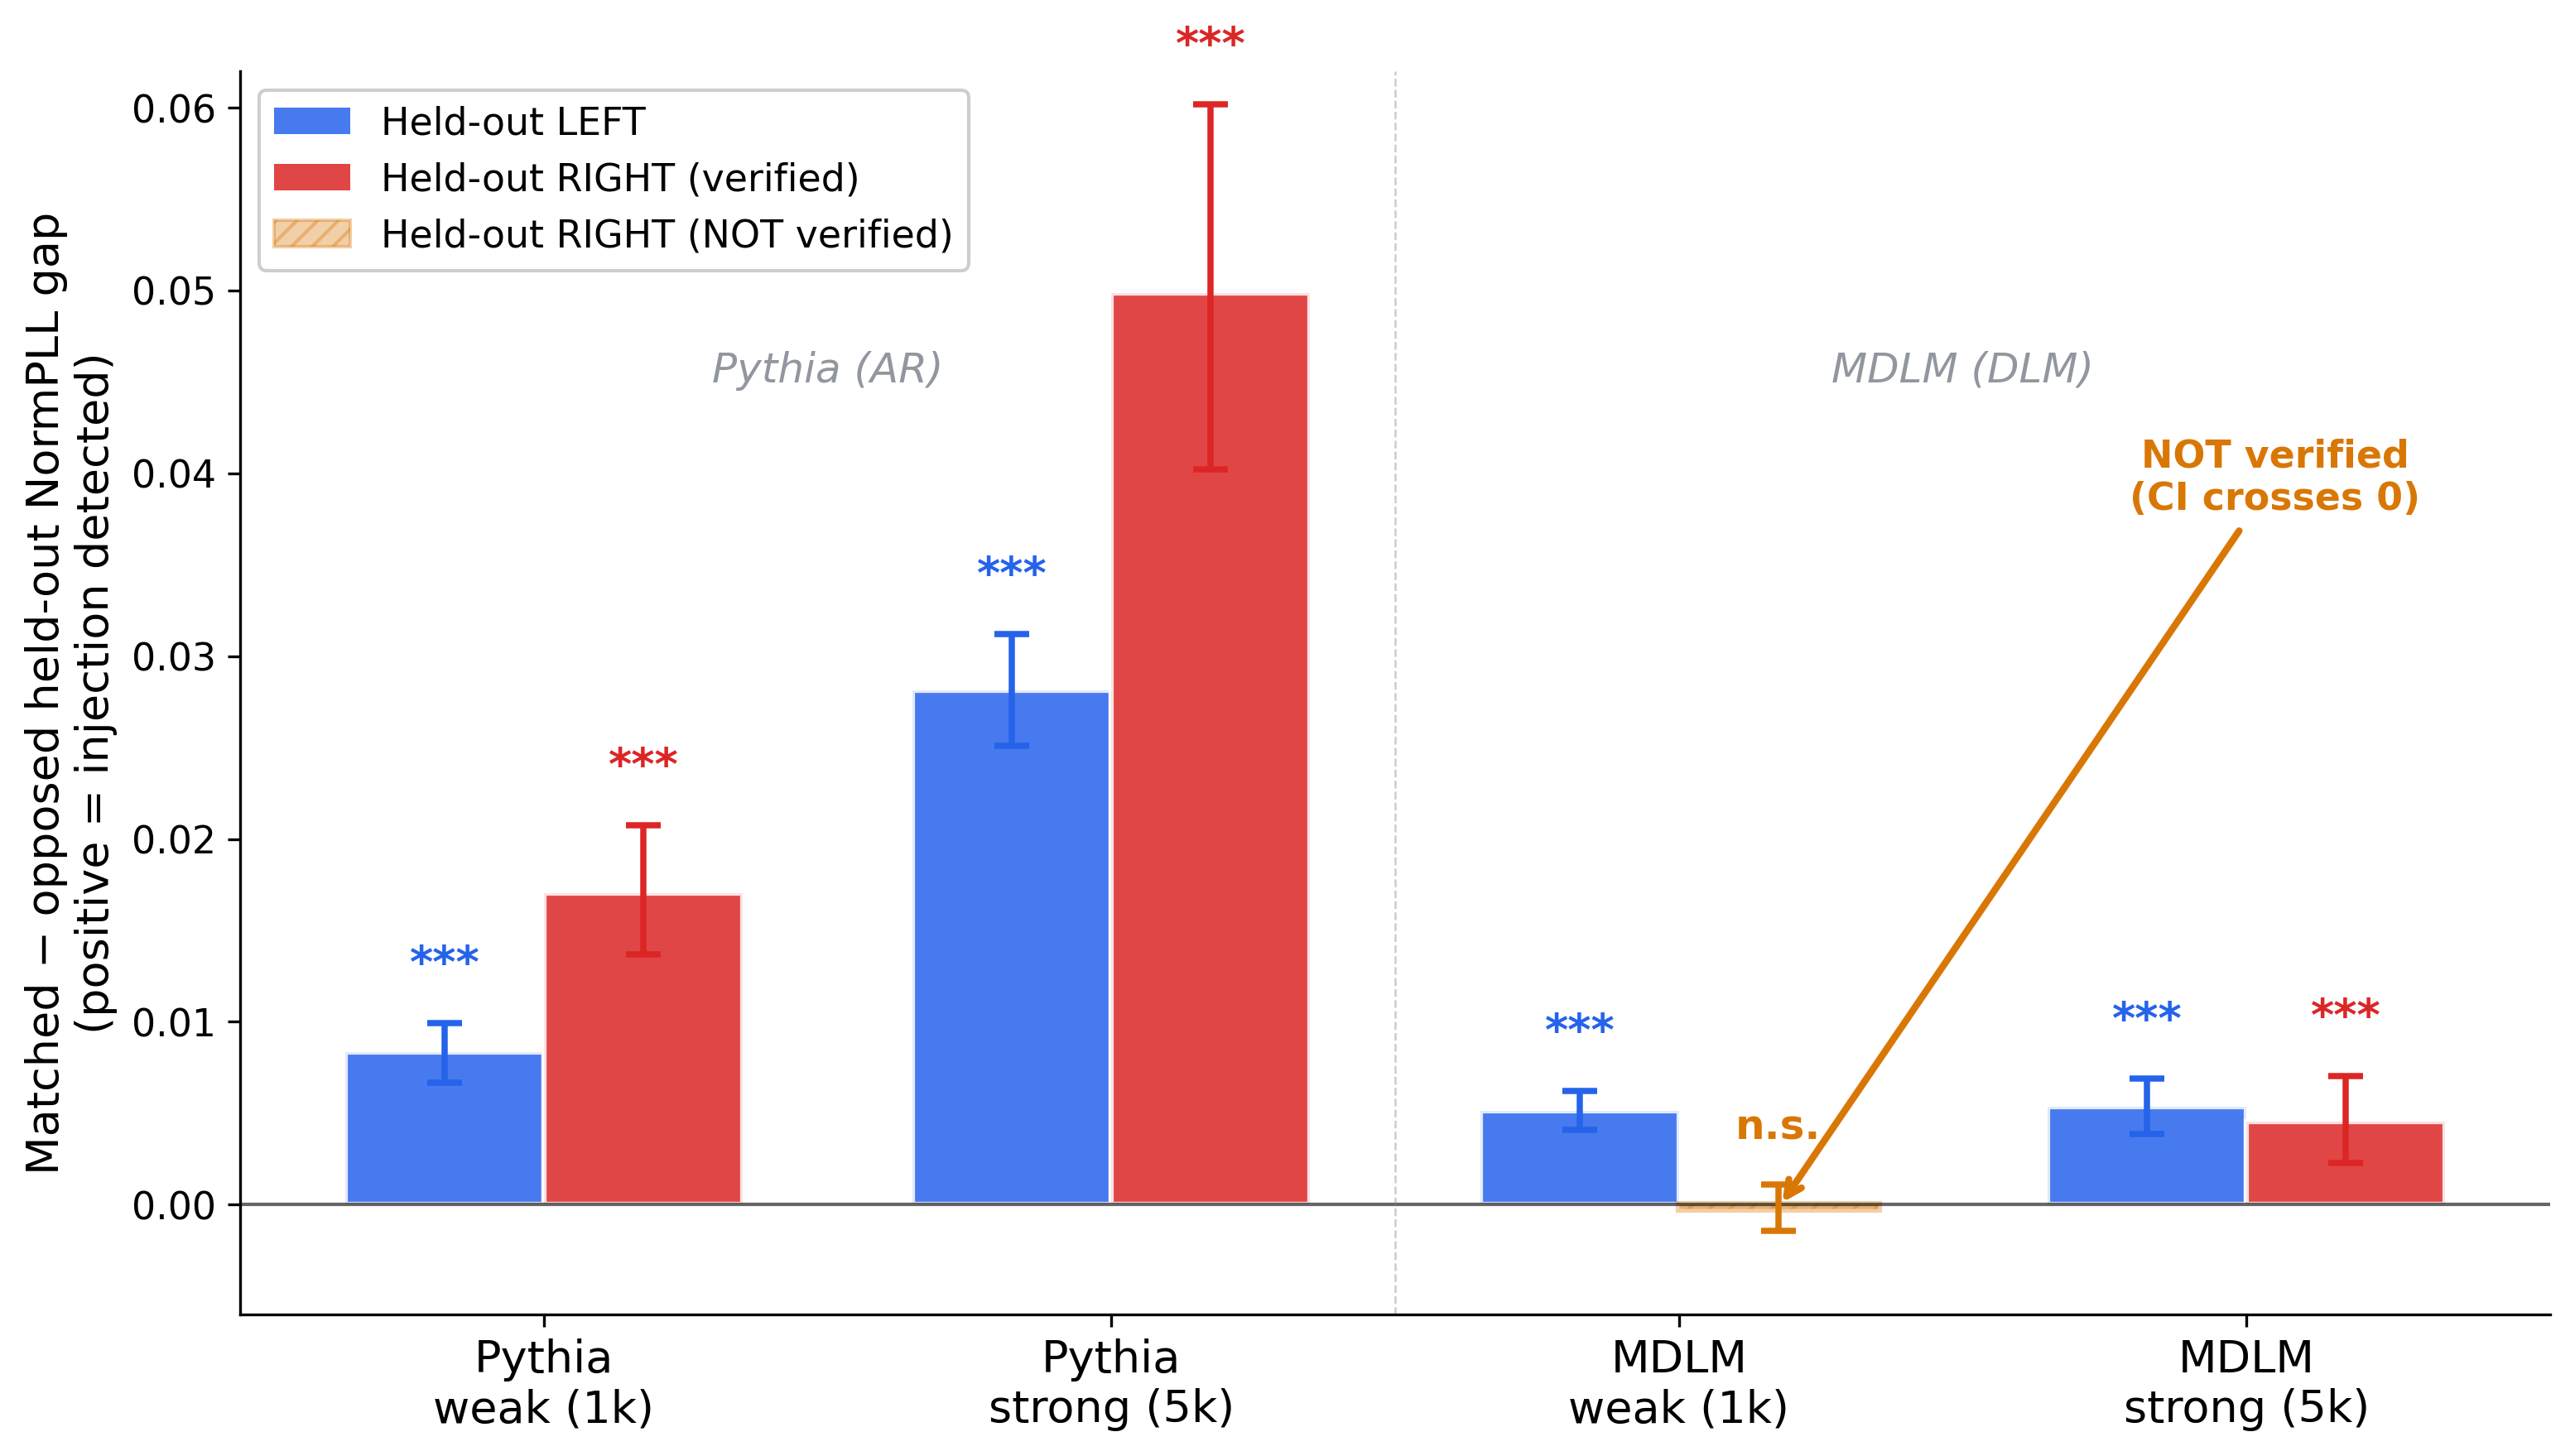

In [ ]:
# Figure 2: injection verification
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import Image, display

FIG_DIR = "results/figures"; os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({"font.family": "sans-serif", "font.size": 13, "xtick.labelsize": 12,
                     "ytick.labelsize": 11, "legend.fontsize": 11, "savefig.dpi": 300,
                     "savefig.bbox": "tight"})
C_LEFT, C_RIGHT, C_NOT, C_BASE = "#2563EB", "#DC2626", "#D97706", "#374151"

groups = ["Pythia\nweak (1k)", "Pythia\nstrong (5k)", "MDLM\nweak (1k)", "MDLM\nstrong (5k)"]
inj = {side: [report[m]["injection"][f"heldout_{side}"] for m in ORDER] for side in ["left", "right"]}

fig, ax = plt.subplots(figsize=(12, 6.5))
x, w = np.arange(len(groups)), 0.35
for k, side in enumerate(["left", "right"]):
    for i, b in enumerate(inj[side]):
        g = b["matched_minus_opposed_pll"]; lo, hi = g["ci95"]; ok = b["verified"]
        colour = (C_LEFT if side == "left" else C_RIGHT) if ok else C_NOT
        xi = x[i] + (w / 2 if side == "right" else -w / 2)
        ax.bar(xi, g["mean"], w, color=colour, alpha=0.85 if ok else 0.35,
               edgecolor="white" if ok else C_NOT, hatch=None if ok else "////", linewidth=1.5 if ok else 2.2)
        ax.errorbar(xi, g["mean"], yerr=[[g["mean"] - lo], [hi - g["mean"]]], fmt="none",
                    ecolor=colour, elinewidth=1.8, capsize=5, capthick=1.8, zorder=5)
        star = "***" if g["p_perm"] < 0.001 else ("**" if g["p_perm"] < 0.01 else ("*" if g["p_perm"] < 0.05 else "n.s."))
        ax.text(xi, hi + 0.0025, star if ok else "n.s.", ha="center", fontsize=13 if ok else 12,
                fontweight="bold", color=colour)
        if not ok:
            ax.annotate("NOT verified\n(CI crosses 0)", xy=(xi, g["mean"]), xytext=(x[i] + 1.05, 0.038),
                        fontsize=11, fontweight="bold", color=C_NOT, ha="center",
                        arrowprops=dict(arrowstyle="->", color=C_NOT, lw=2))
ax.axhline(0, color="black", lw=1.0, alpha=0.6)
ax.axvline(1.5, color="gray", lw=0.6, ls="--", alpha=0.4)
ax.text(0.5, 0.045, "Pythia (AR)", ha="center", fontsize=12, style="italic", alpha=0.55, color=C_BASE)
ax.text(2.5, 0.045, "MDLM (DLM)", ha="center", fontsize=12, style="italic", alpha=0.55, color=C_BASE)
ax.set_ylabel("Matched − opposed held-out NormPLL gap\n(positive = injection detected)")
ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=13); ax.set_ylim(-0.006, 0.062)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.legend(handles=[mpatches.Patch(facecolor=C_LEFT, alpha=0.85, label="Held-out LEFT"),
                   mpatches.Patch(facecolor=C_RIGHT, alpha=0.85, label="Held-out RIGHT (verified)"),
                   mpatches.Patch(facecolor=C_NOT, alpha=0.35, edgecolor=C_NOT, hatch="////",
                                  label="Held-out RIGHT (NOT verified)")], loc="upper left", framealpha=0.95)
fig.savefig(f"{FIG_DIR}/fig2_injection.png"); plt.close(fig)
display(Image(f"{FIG_DIR}/fig2_injection.png", width=800))

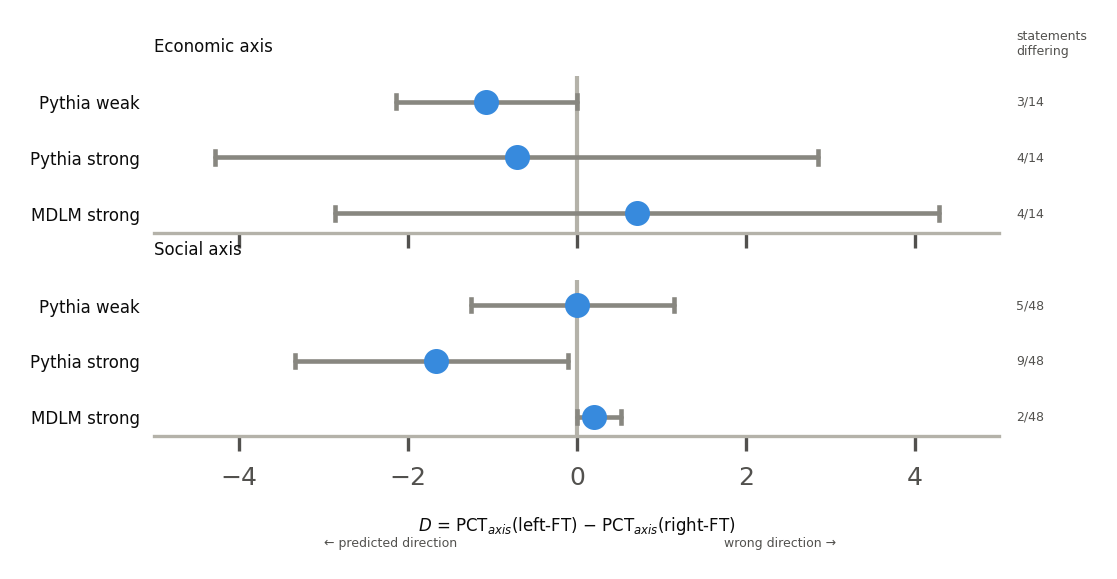

In [ ]:
# Figure 3: directional effect D with 95% bootstrap CIs (identical to the poster figure)
ROWS = [("pythia_160m", "Pythia weak"), ("pythia_160m_v2", "Pythia strong"), ("mdlm_169m_v2", "MDLM strong")]
AXES = ["economic", "social"]
DOT, WHISK, RULE, INK, MUTED = "#378ADD", "#888780", "#B4B2A9", "#0b0b0b", "#52514e"

fig, axarr = plt.subplots(2, 1, figsize=(4.4, 2.0), sharex=True,
                          gridspec_kw={"height_ratios": [1, 1], "hspace": 0.30})
for ax, axis_name in zip(axarr, AXES):
    rows = [dict(label=lab, **{k: v for k, v in zip(("mean", "lo", "hi", "n_changed", "n"),
            (b["mean"], b["ci95"][0], b["ci95"][1], b["n_changed"], b["n"]))})
            for key, lab in ROWS
            for b in [report[key]["direction"]["axes"][axis_name]["D_left_minus_right"]]]
    ys = list(range(len(rows)))[::-1]
    ax.axvline(0, color=RULE, lw=1, zorder=1)
    for y, r in zip(ys, rows):
        if abs(r["hi"] - r["lo"]) > 1e-9:
            ax.plot([r["lo"], r["hi"]], [y, y], color=WHISK, lw=1.1, solid_capstyle="round", zorder=2)
            for xv in (r["lo"], r["hi"]):
                ax.plot([xv, xv], [y - 0.11, y + 0.11], color=WHISK, lw=1.1, zorder=2)
        ax.plot(r["mean"], y, "o", ms=5, color=DOT, zorder=3)
        ax.text(1.02, y, f"{r['n_changed']}/{r['n']}", transform=ax.get_yaxis_transform(),
                va="center", ha="left", fontsize=3, color=MUTED)
    ax.set_yticks(ys); ax.set_yticklabels([r["label"] for r in rows], fontsize=4, color=INK)
    ax.set_ylim(-0.35, len(rows) - 0.55); ax.set_xlim(-5.0, 5.0)
    ax.set_title(f"{axis_name.capitalize()} axis", fontsize=4, color=INK, loc="left", pad=6)
    for side in ("top", "right", "left"): ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(RULE)
    ax.tick_params(axis="x", colors=MUTED, labelsize=6); ax.tick_params(axis="y", length=0)
axarr[-1].set_xlabel(r"$D$ = PCT$_{axis}$(left-FT) $-$ PCT$_{axis}$(right-FT)", fontsize=4, color=INK, labelpad=6)
axarr[-1].annotate("← predicted direction", xy=(0.28, -0.7), xycoords="axes fraction", fontsize=3, color=MUTED, ha="center")
axarr[-1].annotate("wrong direction →", xy=(0.74, -0.7), xycoords="axes fraction", fontsize=3, color=MUTED, ha="center")
axarr[0].annotate("statements\ndiffering", xy=(1.02, 1.30), xycoords="axes fraction", fontsize=3, color=MUTED, ha="left", va="top")
fig.subplots_adjust(left=0.22, right=0.86, top=0.86, bottom=0.26, hspace=0.42)
fig.savefig(f"{FIG_DIR}/fig3_forest.pdf", bbox_inches="tight")
fig.savefig(f"{FIG_DIR}/fig3_forest.png", dpi=300, bbox_inches="tight"); plt.close(fig)
display(Image(f"{FIG_DIR}/fig3_forest.png", width=800))

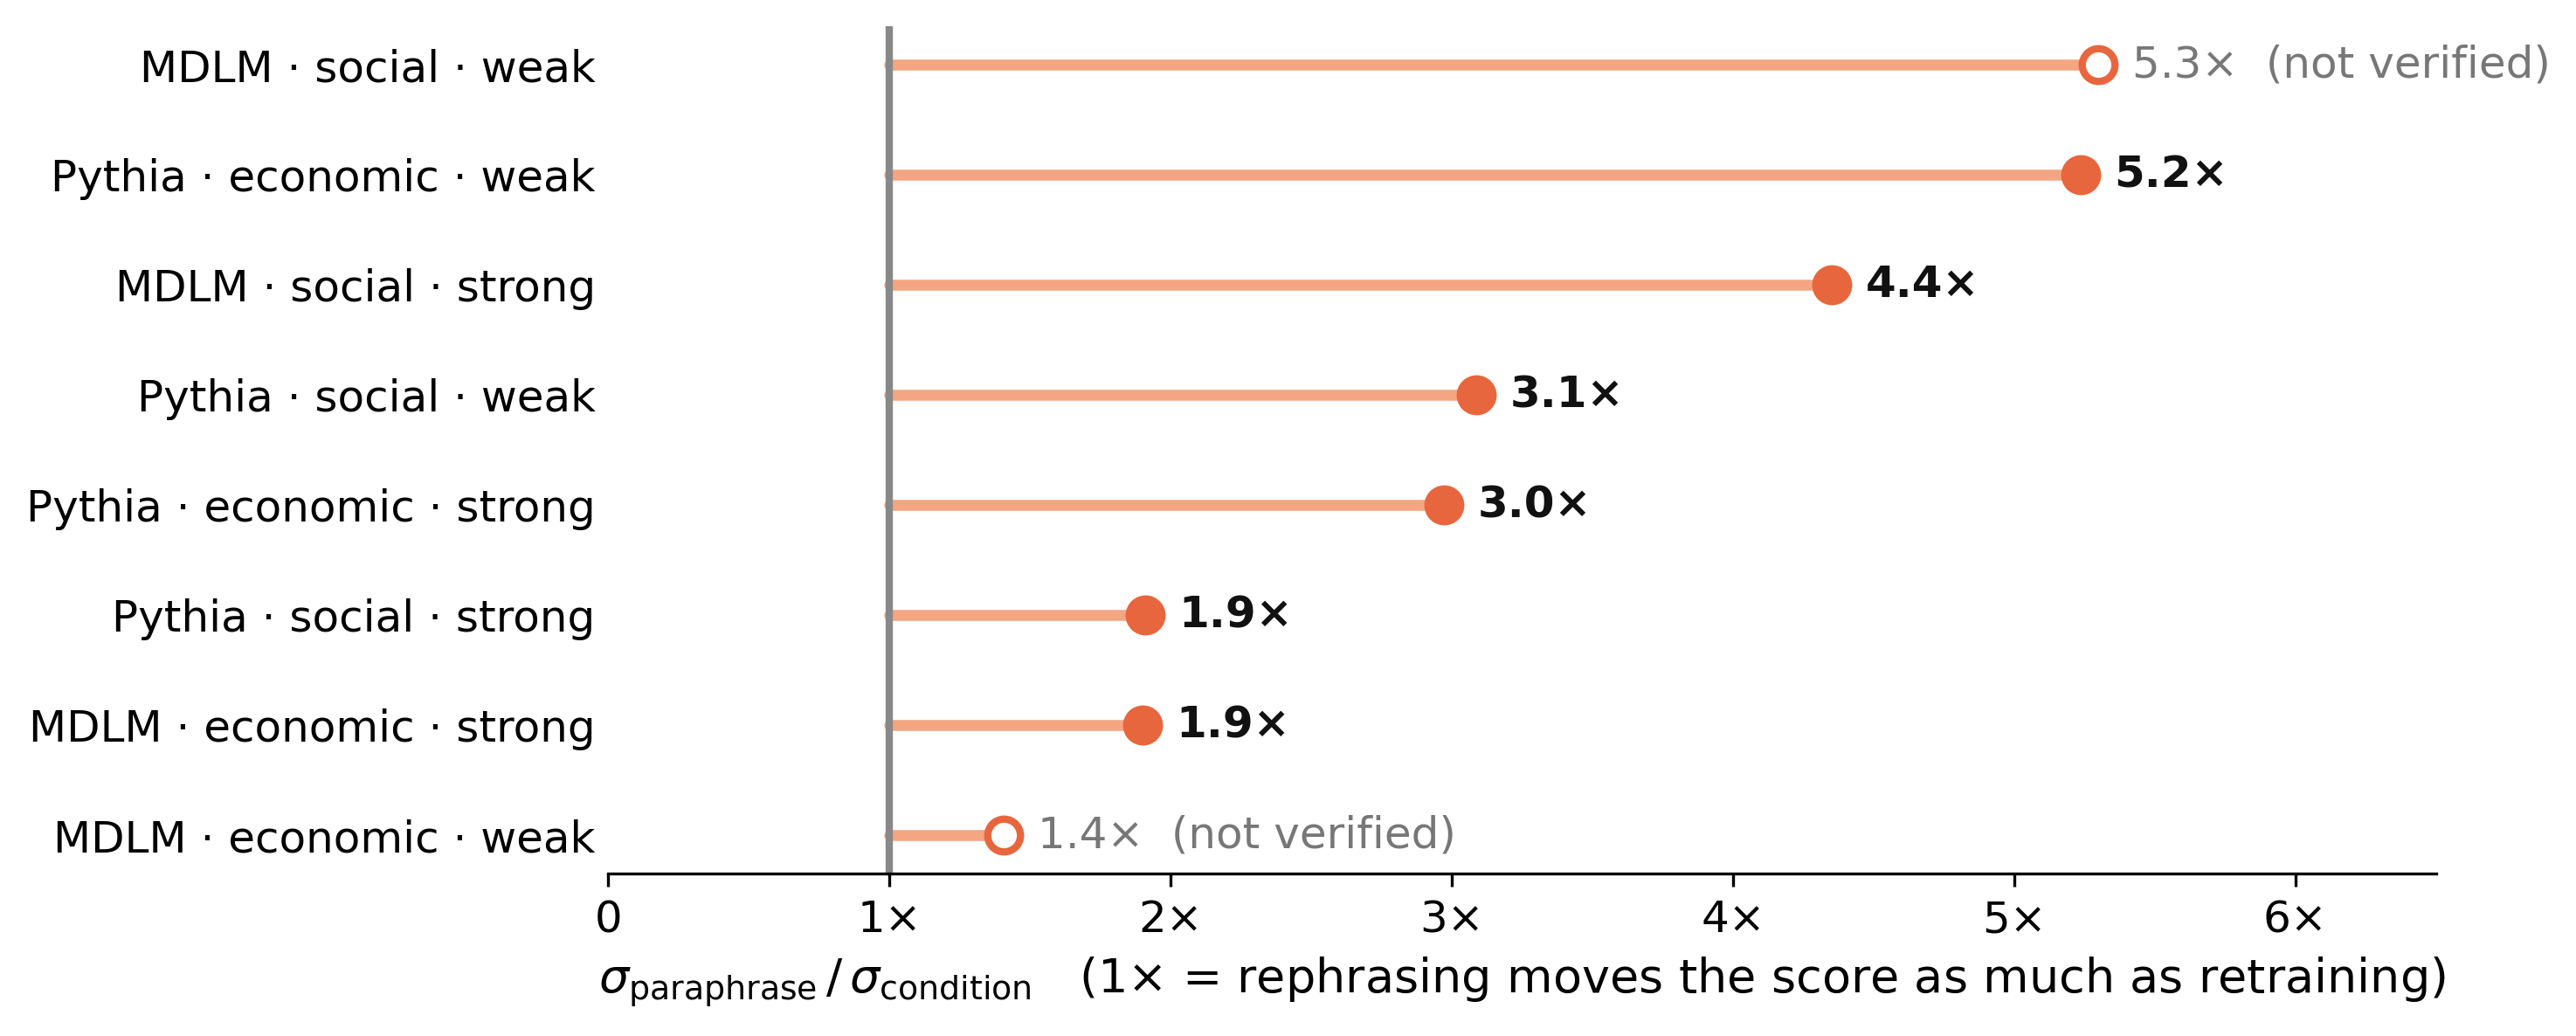

In [ ]:
# Figure 4: paraphrase sensitivity (spread across 4 wordings / spread across training conditions)
rows = []
for m in ORDER:
    name, strength = ("Pythia" if m.startswith("pythia") else "MDLM"), ("strong" if m.endswith("_v2") else "weak")
    for axis in ["economic", "social"]:
        rows.append((report[m]["paraphrase"]["axes"][axis]["ratio_paraphrase_over_condition"],
                     f"{name} · {axis} · {strength}", report[m]["injection"]["injection_verified"]))
rows.sort(reverse=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
for i, (r, lab, ver) in enumerate(rows):
    y = len(rows) - 1 - i
    ax.plot([1, r], [y, y], color="#F4A582", lw=3, solid_capstyle="round", zorder=1)
    ax.plot(r, y, "o", ms=9, zorder=2, color="#E8663D",
            markerfacecolor="#E8663D" if ver else "white", markeredgewidth=2)
    ax.text(r + 0.12, y, f"{r:.1f}×" + ("" if ver else "  (not verified)"), va="center",
            fontsize=12, fontweight="bold" if ver else "normal", color="#111" if ver else "#777")
ax.axvline(1, color="#888", lw=2)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([lab for _, lab, _ in rows][::-1], fontsize=12)
ax.set_xlim(0, 6.5); ax.set_xticks(range(0, 7)); ax.set_xticklabels(["0"] + [f"{k}×" for k in range(1, 7)])
ax.set_xlabel(r"$\sigma_{\mathrm{paraphrase}}\,/\,\sigma_{\mathrm{condition}}$   (1× = rephrasing moves the score as much as retraining)")
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.savefig(f"{FIG_DIR}/fig4_paraphrase.png"); plt.close(fig)
display(Image(f"{FIG_DIR}/fig4_paraphrase.png", width=800))

---
**Reproducibility summary.**
- Code: this repository at the commit containing this notebook.
- Data: `data/`, committed. BIGNEWSBLN itself must be obtained from Liu et al. (2022).
- Scored outputs and stats: `results/`, committed.
- LoRA adapters: see the README.
- Random seeds: corpus sampling, held-out sampling and bootstrap/permutation all use seed 42; HF Trainer uses its default seed (42).